<a href="https://colab.research.google.com/github/Ganasa18/belajar-tensorflow/blob/main/train_class_prompt_labeling_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# =========================================================
# CELL 1 — GOOGLE DRIVE + TRAINING PATH SETUP
# ROUTER V2 MODEL TRAINING
# =========================================================

from google.colab import drive

import os


# =========================================================
# 1. MOUNT GOOGLE DRIVE
# =========================================================

DRIVE_MOUNT = "/content/drive"

drive.mount(
    DRIVE_MOUNT,
    force_remount=False
)

assert os.path.exists(
    f"{DRIVE_MOUNT}/MyDrive"
), "Google Drive belum mounted"


# =========================================================
# 2. STORAGE DIRECTORY
# =========================================================

SAVE_DIR = (
    f"{DRIVE_MOUNT}/MyDrive/router_classifier"
)

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)


# =========================================================
# 3. DATASET PATHS
# =========================================================

CLEAN_TRAIN_PATH = (
    f"{SAVE_DIR}/router_v2_clean_train.csv"
)

REVIEW_SAMPLES_PATH = (
    f"{SAVE_DIR}/router_v2_review_samples.csv"
)


# =========================================================
# 4. MODEL OUTPUT PATHS
# =========================================================

MODEL_PATH = (
    f"{SAVE_DIR}/router_v2_classifier.joblib"
)

BEST_MODEL_PATH = (
    f"{SAVE_DIR}/router_v2_classifier_best.joblib"
)

METRICS_PATH = (
    f"{SAVE_DIR}/router_v2_training_metrics.json"
)

PREDICTIONS_PATH = (
    f"{SAVE_DIR}/router_v2_test_predictions.csv"
)

ERROR_ANALYSIS_PATH = (
    f"{SAVE_DIR}/router_v2_error_analysis.csv"
)


# =========================================================
# 5. VALIDATION
# =========================================================

if not os.path.exists(CLEAN_TRAIN_PATH):

    raise FileNotFoundError(
        f"Clean dataset tidak ditemukan:\n"
        f"{CLEAN_TRAIN_PATH}"
    )


# =========================================================
# 6. STATUS
# =========================================================

print()
print("=" * 70)
print("ROUTER V2 — MODEL TRAINING STORAGE")
print("=" * 70)

print(
    "SAVE_DIR       :",
    SAVE_DIR
)

print(
    "Clean dataset  :",
    CLEAN_TRAIN_PATH
)

print(
    "Review samples :",
    REVIEW_SAMPLES_PATH
)

print(
    "Model output   :",
    MODEL_PATH
)

print(
    "Best model     :",
    BEST_MODEL_PATH
)

print(
    "Metrics        :",
    METRICS_PATH
)

print("=" * 70)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

ROUTER V2 — MODEL TRAINING STORAGE
SAVE_DIR       : /content/drive/MyDrive/router_classifier
Clean dataset  : /content/drive/MyDrive/router_classifier/router_v2_clean_train.csv
Review samples : /content/drive/MyDrive/router_classifier/router_v2_review_samples.csv
Model output   : /content/drive/MyDrive/router_classifier/router_v2_classifier.joblib
Best model     : /content/drive/MyDrive/router_classifier/router_v2_classifier_best.joblib
Metrics        : /content/drive/MyDrive/router_classifier/router_v2_training_metrics.json


In [4]:
# =========================================================
# CELL 2 — ROUTING TAXONOMY
# ROUTER V2 MODEL TRAINING
# =========================================================

LABELS = [
    "SIMPLE",
    "GENERAL",
    "REASONING",
    "CODING_SIMPLE",
    "CODING_COMPLEX",
    "TRANSFORM",
    "CREATIVE",
]


CATEGORY_DESCRIPTIONS = {

    "SIMPLE":
        "Simple factual questions, definitions, easy lookup, "
        "basic calculations, or very short tasks requiring "
        "little to no reasoning.",

    "GENERAL":
        "Normal assistant questions and explanations that "
        "require some understanding but do not require "
        "substantial multi-step reasoning, comparison, "
        "planning, or software engineering analysis.",

    "REASONING":
        "Non-coding analytical tasks requiring comparison, "
        "planning, trade-offs, deduction, mathematics, "
        "decision making, or multi-step reasoning. "
        "Technology comparisons without actual software "
        "debugging or implementation belong here.",

    "CODING_SIMPLE":
        "Small programming tasks such as regex, SQL, syntax "
        "correction, short scripts, small functions, simple "
        "code modification, or straightforward implementation.",

    "CODING_COMPLEX":
        "Software engineering tasks requiring substantial "
        "technical reasoning involving debugging, architecture, "
        "security, concurrency, performance, databases, "
        "distributed systems, backend/frontend systems, "
        "or multi-component implementation.",

    "TRANSFORM":
        "Tasks whose main purpose is transforming existing "
        "user-provided content, including translation, "
        "summarization, rewriting, extraction, formatting, "
        "shortening, restructuring, or conversion.",

    "CREATIVE":
        "Creative generation and ideation such as stories, "
        "dialogue, slogans, names, concepts, fictional content, "
        "brainstorming, characters, scenarios, "
        "or creative variations.",
}


# =========================================================
# VALIDATE TAXONOMY
# =========================================================

for label in LABELS:

    if label not in CATEGORY_DESCRIPTIONS:

        raise ValueError(
            f"Missing description: {label}"
        )


print()
print("=" * 70)
print("ROUTING TAXONOMY")
print("=" * 70)

for i, label in enumerate(
    LABELS,
    start=1
):

    print(
        f"{i}. {label}"
    )

print()
print(
    "Total labels:",
    len(LABELS)
)

print("=" * 70)


ROUTING TAXONOMY
1. SIMPLE
2. GENERAL
3. REASONING
4. CODING_SIMPLE
5. CODING_COMPLEX
6. TRANSFORM
7. CREATIVE

Total labels: 7


In [7]:
# =========================================================
# CELL 3 — LOAD + AUTO-DETECT DATASET COLUMNS
# ROUTER V2 MODEL TRAINING
# =========================================================

import pandas as pd


# =========================================================
# LOAD
# =========================================================

df = pd.read_csv(
    CLEAN_TRAIN_PATH
)


# =========================================================
# COLUMN DETECTION
# =========================================================

print()
print("=" * 70)
print("DATASET COLUMNS")
print("=" * 70)

print(
    list(df.columns)
)


# Kandidat nama kolom prompt/text
TEXT_CANDIDATES = [
    "text",
    "prompt",
    "request",
    "user_prompt",
    "query",
    "input",
    "content",
]

LABEL_CANDIDATES = [
    "label",
    "target",
    "category",
    "route",
]


TEXT_COLUMN = None
LABEL_COLUMN = None


for col in TEXT_CANDIDATES:

    if col in df.columns:

        TEXT_COLUMN = col
        break


for col in LABEL_CANDIDATES:

    if col in df.columns:

        LABEL_COLUMN = col
        break


# =========================================================
# VALIDATION
# =========================================================

if TEXT_COLUMN is None:

    raise ValueError(
        "Tidak bisa menemukan kolom prompt/text.\n"
        f"Kolom tersedia: {list(df.columns)}"
    )


if LABEL_COLUMN is None:

    raise ValueError(
        "Tidak bisa menemukan kolom label.\n"
        f"Kolom tersedia: {list(df.columns)}"
    )


print()
print(
    "Detected text column :",
    TEXT_COLUMN
)

print(
    "Detected label column:",
    LABEL_COLUMN
)


# =========================================================
# STANDARDIZE COLUMN NAMES
#
# Mulai dari sini semua cell selalu pakai:
# text
# label
# =========================================================

if TEXT_COLUMN != "text":

    df = df.rename(
        columns={
            TEXT_COLUMN: "text"
        }
    )


if LABEL_COLUMN != "label":

    df = df.rename(
        columns={
            LABEL_COLUMN: "label"
        }
    )


# =========================================================
# BASIC INFO
# =========================================================

print()
print("=" * 70)
print("CLEAN DATASET INSPECTION")
print("=" * 70)

print(
    "Shape:",
    df.shape
)

print()

print(
    "Standardized columns:",
    list(df.columns)
)

print()

display(
    df.head(10)
)


# =========================================================
# DISTRIBUTION
# =========================================================

print()
print("=" * 70)
print("LABEL DISTRIBUTION")
print("=" * 70)

distribution = (
    df["label"]
    .value_counts()
    .reindex(
        LABELS,
        fill_value=0
    )
)

print(
    distribution
)

print()

print(
    "Total:",
    len(df)
)


# =========================================================
# NULL CHECK
# =========================================================

print()
print("=" * 70)
print("NULL CHECK")
print("=" * 70)

print(
    df[
        [
            "text",
            "label"
        ]
    ]
    .isna()
    .sum()
)


print()
print("=" * 70)
print("CELL 3 COMPLETE")
print("=" * 70)


DATASET COLUMNS
['prompt', 'label']

Detected text column : prompt
Detected label column: label

CLEAN DATASET INSPECTION
Shape: (327, 2)

Standardized columns: ['text', 'label']



,text,label
0,Beri saya pertanyaan untuk ditanyakan kepada s...,CREATIVE
1,Jelaskan seperti apa hari-hari musim panas pad...,GENERAL
2,Tulis ulang kalimat berikut untuk mendapatkan ...,TRANSFORM
3,Tuliskan sebuah cerita tentang seorang wanita ...,CREATIVE
4,Jelaskan kasus penggunaan potensial untuk tekn...,GENERAL
5,Buatlah masalah yang dapat diselesaikan dengan...,CREATIVE
6,Hasilkan laporan yang merangkum temuan utama m...,TRANSFORM
7,Buatlah contoh dua orang sedang berbincang ten...,CREATIVE
8,"Buatlah puisi pendek dengan kata “bunga”, “war...",CREATIVE
9,Berikan dua contoh situasi di mana Anda mengha...,GENERAL



LABEL DISTRIBUTION
label
SIMPLE            39
GENERAL           55
REASONING         37
CODING_SIMPLE     34
CODING_COMPLEX    87
TRANSFORM         43
CREATIVE          32
Name: count, dtype: int64

Total: 327

NULL CHECK
text     0
label    0
dtype: int64

CELL 3 COMPLETE


In [8]:
# =========================================================
# CELL 4 — DATA QUALITY CLEANUP
# ROUTER V2 MODEL TRAINING
# =========================================================

import pandas as pd


# =========================================================
# COPY WORKING DATAFRAME
# =========================================================

df_clean = df.copy()


# =========================================================
# NORMALIZE LABEL
# =========================================================

df_clean["label"] = (
    df_clean["label"]
    .astype(str)
    .str.strip()
    .str.upper()
)


# =========================================================
# NORMALIZE TEXT
# =========================================================

df_clean["text"] = (
    df_clean["text"]
    .fillna("")
    .astype(str)
    .str.strip()
)


# =========================================================
# REMOVE EMPTY TEXT
# =========================================================

before_empty = len(df_clean)

df_clean = df_clean[
    df_clean["text"].str.len() > 0
].copy()

removed_empty = (
    before_empty
    - len(df_clean)
)


# =========================================================
# REMOVE INVALID LABELS
# =========================================================

before_invalid = len(df_clean)

df_clean = df_clean[
    df_clean["label"].isin(
        LABELS
    )
].copy()

removed_invalid = (
    before_invalid
    - len(df_clean)
)


# =========================================================
# REMOVE EXACT DUPLICATES
#
# text + label sama persis
# =========================================================

before_duplicates = len(df_clean)

df_clean = (
    df_clean
    .drop_duplicates(
        subset=[
            "text",
            "label"
        ],
        keep="first"
    )
    .reset_index(
        drop=True
    )
)

removed_duplicates = (
    before_duplicates
    - len(df_clean)
)


# =========================================================
# CONFLICT CHECK
#
# text sama tetapi label berbeda
# jangan otomatis dibuang
# =========================================================

conflict_counts = (
    df_clean
    .groupby("text")["label"]
    .nunique()
)

conflicting_texts = (
    conflict_counts[
        conflict_counts > 1
    ]
    .index
    .tolist()
)


# =========================================================
# FINAL DISTRIBUTION
# =========================================================

distribution = (
    df_clean["label"]
    .value_counts()
    .reindex(
        LABELS,
        fill_value=0
    )
)


# =========================================================
# STATUS
# =========================================================

print()
print("=" * 70)
print("DATA QUALITY CLEANUP")
print("=" * 70)

print(
    "Original samples        :",
    len(df)
)

print(
    "Removed empty text      :",
    removed_empty
)

print(
    "Removed invalid labels  :",
    removed_invalid
)

print(
    "Removed exact duplicates:",
    removed_duplicates
)

print(
    "Remaining conflicts     :",
    len(conflicting_texts)
)

print(
    "Final samples           :",
    len(df_clean)
)

print()

print(
    "Final distribution:"
)

print(
    distribution
)

print("=" * 70)


# =========================================================
# SAFETY CHECKS
# =========================================================

missing_labels = [
    label
    for label in LABELS
    if distribution[label] == 0
]

if missing_labels:

    raise RuntimeError(
        "Ada label yang kehilangan seluruh sample: "
        + ", ".join(
            missing_labels
        )
    )


if conflicting_texts:

    print()
    print(
        "WARNING: ditemukan text yang memiliki "
        "lebih dari satu label."
    )

    display(
        df_clean[
            df_clean["text"].isin(
                conflicting_texts
            )
        ]
        .sort_values(
            "text"
        )
        .head(50)
    )

else:

    print()
    print(
        "PASS — tidak ada conflicting labels."
    )


print()
print("=" * 70)
print("CELL 4 COMPLETE")
print("=" * 70)


DATA QUALITY CLEANUP
Original samples        : 327
Removed empty text      : 0
Removed invalid labels  : 0
Removed exact duplicates: 0
Remaining conflicts     : 0
Final samples           : 327

Final distribution:
label
SIMPLE            39
GENERAL           55
REASONING         37
CODING_SIMPLE     34
CODING_COMPLEX    87
TRANSFORM         43
CREATIVE          32
Name: count, dtype: int64

PASS — tidak ada conflicting labels.

CELL 4 COMPLETE


In [9]:
# =========================================================
# CELL 5 — STRATIFIED TRAIN / TEST SPLIT
# ROUTER V2 MODEL TRAINING
# =========================================================

from sklearn.model_selection import train_test_split


# =========================================================
# FEATURES + TARGET
# =========================================================

X = df_clean["text"].copy()
y = df_clean["label"].copy()


# =========================================================
# STRATIFIED SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# =========================================================
# STATUS
# =========================================================

print()
print("=" * 70)
print("TRAIN / TEST SPLIT")
print("=" * 70)

print("Total samples :", len(df_clean))
print("Train samples :", len(X_train))
print("Test samples  :", len(X_test))

print()
print("TRAIN DISTRIBUTION")
print(
    y_train
    .value_counts()
    .reindex(
        LABELS,
        fill_value=0
    )
)

print()
print("TEST DISTRIBUTION")
print(
    y_test
    .value_counts()
    .reindex(
        LABELS,
        fill_value=0
    )
)

print("=" * 70)


# =========================================================
# SAFETY CHECK
# =========================================================

assert set(y_train.unique()) == set(LABELS), (
    "Train set kehilangan label."
)

assert set(y_test.unique()) == set(LABELS), (
    "Test set kehilangan label."
)

print()
print("PASS — semua label ada di train dan test.")


TRAIN / TEST SPLIT
Total samples : 327
Train samples : 261
Test samples  : 66

TRAIN DISTRIBUTION
label
SIMPLE            31
GENERAL           44
REASONING         30
CODING_SIMPLE     27
CODING_COMPLEX    69
TRANSFORM         34
CREATIVE          26
Name: count, dtype: int64

TEST DISTRIBUTION
label
SIMPLE             8
GENERAL           11
REASONING          7
CODING_SIMPLE      7
CODING_COMPLEX    18
TRANSFORM          9
CREATIVE           6
Name: count, dtype: int64

PASS — semua label ada di train dan test.


In [10]:
# =========================================================
# CELL 6 — BASELINE MODEL
# TF-IDF + LOGISTIC REGRESSION
# =========================================================

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression


# =========================================================
# MODEL
# =========================================================

baseline_model = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=1,
                max_df=0.98,
                max_features=20000,
                sublinear_tf=True,
            )
        ),

        (
            "classifier",
            LogisticRegression(
                C=2.0,
                max_iter=3000,
                class_weight="balanced",
                random_state=42,
            )
        ),
    ]
)


# =========================================================
# TRAIN
# =========================================================

print()
print("=" * 70)
print("TRAIN BASELINE MODEL")
print("=" * 70)

baseline_model.fit(
    X_train,
    y_train
)

print("Training complete.")

print("=" * 70)


TRAIN BASELINE MODEL
Training complete.


In [11]:
# =========================================================
# CELL 7 — BASELINE EVALUATION
# ROUTER V2 MODEL TRAINING
# =========================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
)


# =========================================================
# PREDICT
# =========================================================

y_pred = baseline_model.predict(
    X_test
)


# =========================================================
# PROBABILITY / CONFIDENCE
# =========================================================

y_proba = baseline_model.predict_proba(
    X_test
)

confidence = np.max(
    y_proba,
    axis=1
)


# =========================================================
# METRICS
# =========================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

macro_precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)


# =========================================================
# DISPLAY
# =========================================================

print()
print("=" * 70)
print("BASELINE RESULTS")
print("=" * 70)

print(f"Accuracy        : {accuracy:.4f}")
print(f"Macro F1        : {macro_f1:.4f}")
print(f"Weighted F1     : {weighted_f1:.4f}")
print(f"Macro Precision : {macro_precision:.4f}")
print(f"Macro Recall    : {macro_recall:.4f}")

print()
print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred,
        labels=LABELS,
        digits=4,
        zero_division=0
    )
)


# =========================================================
# RESULT DATAFRAME
# =========================================================

prediction_df = pd.DataFrame(
    {
        "text": X_test.values,
        "true_label": y_test.values,
        "pred_label": y_pred,
        "confidence": confidence,
    }
)

prediction_df["correct"] = (
    prediction_df["true_label"]
    == prediction_df["pred_label"]
)

print()
print(
    "Correct:",
    int(
        prediction_df["correct"].sum()
    ),
    "/",
    len(prediction_df)
)


BASELINE RESULTS
Accuracy        : 0.7879
Macro F1        : 0.7415
Weighted F1     : 0.7629
Macro Precision : 0.7488
Macro Recall    : 0.7555

CLASSIFICATION REPORT
                precision    recall  f1-score   support

        SIMPLE     0.3333    0.1250    0.1818         8
       GENERAL     0.7273    0.7273    0.7273        11
     REASONING     0.6667    0.8571    0.7500         7
 CODING_SIMPLE     0.8571    0.8571    0.8571         7
CODING_COMPLEX     0.8571    1.0000    0.9231        18
     TRANSFORM     0.8000    0.8889    0.8421         9
      CREATIVE     1.0000    0.8333    0.9091         6

      accuracy                         0.7879        66
     macro avg     0.7488    0.7555    0.7415        66
  weighted avg     0.7570    0.7879    0.7629        66


Correct: 52 / 66


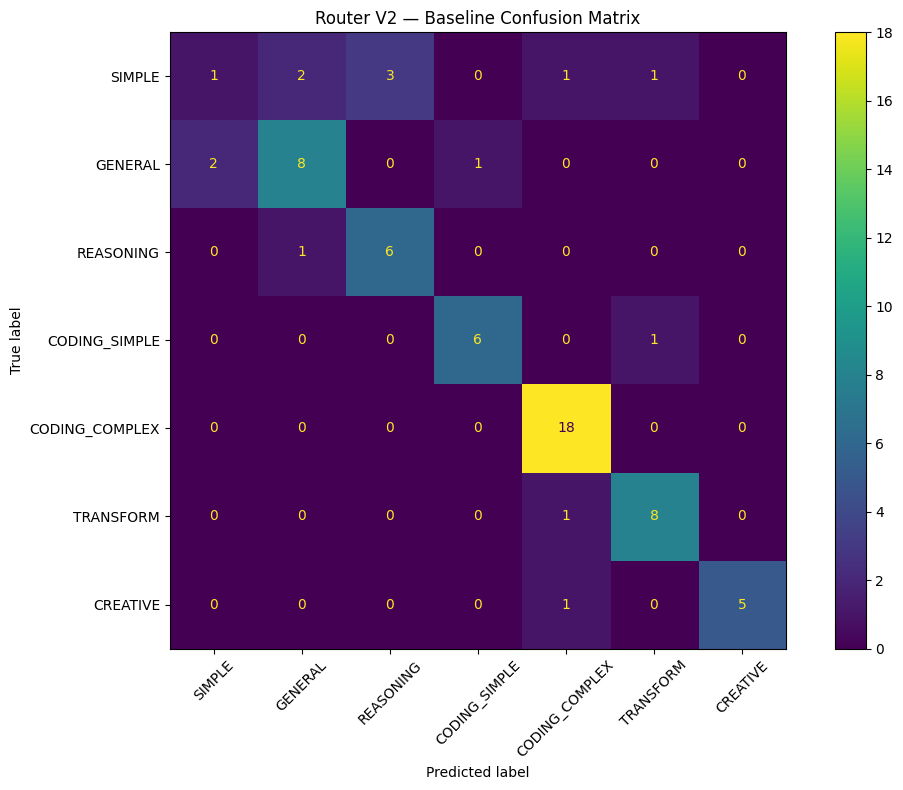


HIGH CONFIDENCE WRONG PREDICTIONS


,true_label,pred_label,confidence,text
39,SIMPLE,GENERAL,0.490044,Apa contoh karbohidrat kompleks?
25,REASONING,GENERAL,0.374743,Apa perbedaan antara synchronous dan asynchron...
5,GENERAL,SIMPLE,0.312566,Apa itu syntax dasar loop di Ruby?
0,CODING_SIMPLE,TRANSFORM,0.309728,"Hapus duplikat daftar berikut.\nangka = [1, 4,..."
44,GENERAL,CODING_SIMPLE,0.297097,Help me understand how to use map() in JavaScript
18,GENERAL,SIMPLE,0.287076,Apa peran pemerintah dalam perekonomian?
13,SIMPLE,GENERAL,0.267669,Hari apa setelah Jumat?
20,SIMPLE,CODING_COMPLEX,0.264809,Who wrote 'Romeo and Juliet'?
6,SIMPLE,REASONING,0.223364,Tulis persamaan untuk menghitung total biaya s...
40,SIMPLE,REASONING,0.219552,Who wrote the play 'Romeo and Juliet'?



LOW CONFIDENCE SAMPLES


,true_label,pred_label,confidence,correct,text
61,SIMPLE,REASONING,0.175910,False,When was the Declaration of Independence signed?
62,CREATIVE,CODING_COMPLEX,0.182604,False,Come up with a catchy slogan for a reusable co...
54,GENERAL,GENERAL,0.192447,True,Jelaskan kualitas seorang manajer proyek yang ...
34,SIMPLE,TRANSFORM,0.192801,False,List the three primary colors.
11,CREATIVE,CREATIVE,0.194918,True,Buatkan karakter fiksi utama untuk novel komed...
17,TRANSFORM,CODING_COMPLEX,0.207221,False,Extract the main arguments from the following ...
64,CREATIVE,CREATIVE,0.209812,True,Buatlah masalah yang dapat diselesaikan dengan...
59,TRANSFORM,TRANSFORM,0.214307,True,Extract all email addresses from this text
65,CODING_COMPLEX,CODING_COMPLEX,0.216522,True,Bagaimana mengimplementasikan load balancer be...
40,SIMPLE,REASONING,0.219552,False,Who wrote the play 'Romeo and Juliet'?



TOP CONFUSION PAIRS


,true_label,pred_label,count
7,SIMPLE,REASONING,3
3,GENERAL,SIMPLE,2
6,SIMPLE,GENERAL,2
0,CODING_SIMPLE,TRANSFORM,1
1,CREATIVE,CODING_COMPLEX,1
2,GENERAL,CODING_SIMPLE,1
5,SIMPLE,CODING_COMPLEX,1
4,REASONING,GENERAL,1
8,SIMPLE,TRANSFORM,1
9,TRANSFORM,CODING_COMPLEX,1



CELL 8 COMPLETE
Predictions saved: /content/drive/MyDrive/router_classifier/router_v2_test_predictions.csv
Errors saved     : /content/drive/MyDrive/router_classifier/router_v2_error_analysis.csv


In [12]:
# =========================================================
# CELL 8 — CONFUSION MATRIX + ERROR ANALYSIS
# ROUTER V2 MODEL TRAINING
# =========================================================

import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
)


# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=LABELS
)

fig, ax = plt.subplots(
    figsize=(11, 8)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=LABELS
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d"
)

plt.title(
    "Router V2 — Baseline Confusion Matrix"
)

plt.tight_layout()
plt.show()


# =========================================================
# WRONG PREDICTIONS
# =========================================================

wrong_df = (
    prediction_df[
        prediction_df["correct"] == False
    ]
    .copy()
)


# =========================================================
# HIGH CONFIDENCE WRONG
#
# Ini paling penting:
# model salah tapi yakin.
# =========================================================

high_conf_wrong = (
    wrong_df
    .sort_values(
        "confidence",
        ascending=False
    )
)


print()
print("=" * 70)
print("HIGH CONFIDENCE WRONG PREDICTIONS")
print("=" * 70)

display(
    high_conf_wrong[
        [
            "true_label",
            "pred_label",
            "confidence",
            "text",
        ]
    ]
    .head(30)
)


# =========================================================
# LOW CONFIDENCE SAMPLES
# =========================================================

low_confidence_df = (
    prediction_df
    .sort_values(
        "confidence",
        ascending=True
    )
)


print()
print("=" * 70)
print("LOW CONFIDENCE SAMPLES")
print("=" * 70)

display(
    low_confidence_df[
        [
            "true_label",
            "pred_label",
            "confidence",
            "correct",
            "text",
        ]
    ]
    .head(30)
)


# =========================================================
# CONFUSION PAIRS
# =========================================================

confusion_pairs = (
    wrong_df
    .groupby(
        [
            "true_label",
            "pred_label"
        ]
    )
    .size()
    .reset_index(
        name="count"
    )
    .sort_values(
        "count",
        ascending=False
    )
)


print()
print("=" * 70)
print("TOP CONFUSION PAIRS")
print("=" * 70)

display(
    confusion_pairs
)


# =========================================================
# SAVE PREDICTIONS
# =========================================================

prediction_df.to_csv(
    PREDICTIONS_PATH,
    index=False
)

wrong_df.to_csv(
    ERROR_ANALYSIS_PATH,
    index=False
)

print()
print("=" * 70)
print("CELL 8 COMPLETE")
print("=" * 70)

print(
    "Predictions saved:",
    PREDICTIONS_PATH
)

print(
    "Errors saved     :",
    ERROR_ANALYSIS_PATH
)

print("=" * 70)

In [15]:
# =========================================================
# CELL 9 — SIMPLE ERROR ANALYSIS
# ROUTER V2 MODEL TRAINING
# =========================================================

simple_errors = prediction_df[
    (
        (prediction_df["true_label"] == "SIMPLE")
        |
        (prediction_df["pred_label"] == "SIMPLE")
    )
].copy()

simple_errors = simple_errors.sort_values(
    [
        "correct",
        "confidence"
    ],
    ascending=[
        True,
        False
    ]
)

print()
print("=" * 70)
print("SIMPLE ERROR ANALYSIS")
print("=" * 70)

display(
    simple_errors[
        [
            "true_label",
            "pred_label",
            "confidence",
            "correct",
            "text"
        ]
    ]
)

print()
print("True SIMPLE samples:")
print(
    (prediction_df["true_label"] == "SIMPLE").sum()
)

print(
    "Correct SIMPLE:",
    (
        (prediction_df["true_label"] == "SIMPLE")
        &
        (prediction_df["pred_label"] == "SIMPLE")
    ).sum()
)


SIMPLE ERROR ANALYSIS


,true_label,pred_label,confidence,correct,text
39,SIMPLE,GENERAL,0.490044,False,Apa contoh karbohidrat kompleks?
5,GENERAL,SIMPLE,0.312566,False,Apa itu syntax dasar loop di Ruby?
18,GENERAL,SIMPLE,0.287076,False,Apa peran pemerintah dalam perekonomian?
13,SIMPLE,GENERAL,0.267669,False,Hari apa setelah Jumat?
20,SIMPLE,CODING_COMPLEX,0.264809,False,Who wrote 'Romeo and Juliet'?
6,SIMPLE,REASONING,0.223364,False,Tulis persamaan untuk menghitung total biaya s...
40,SIMPLE,REASONING,0.219552,False,Who wrote the play 'Romeo and Juliet'?
34,SIMPLE,TRANSFORM,0.192801,False,List the three primary colors.
61,SIMPLE,REASONING,0.175910,False,When was the Declaration of Independence signed?
56,SIMPLE,SIMPLE,0.439467,True,Berapa jumlah provinsi di Indonesia?



True SIMPLE samples:
8
Correct SIMPLE: 1


In [16]:
# =========================================================
# CELL 10 — CONFUSION PAIRS ANALYSIS
# ROUTER V2 MODEL TRAINING
# =========================================================

wrong_df = prediction_df[
    prediction_df["correct"] == False
].copy()

confusion_pairs = (
    wrong_df
    .groupby(
        [
            "true_label",
            "pred_label"
        ]
    )
    .size()
    .reset_index(
        name="count"
    )
    .sort_values(
        "count",
        ascending=False
    )
)

print()
print("=" * 70)
print("TOP CONFUSION PAIRS")
print("=" * 70)

display(
    confusion_pairs
)

print()
print("=" * 70)
print("SIMPLE CONFUSION ONLY")
print("=" * 70)

simple_confusions = confusion_pairs[
    (
        (confusion_pairs["true_label"] == "SIMPLE")
        |
        (confusion_pairs["pred_label"] == "SIMPLE")
    )
]

display(
    simple_confusions
)


TOP CONFUSION PAIRS


,true_label,pred_label,count
7,SIMPLE,REASONING,3
3,GENERAL,SIMPLE,2
6,SIMPLE,GENERAL,2
0,CODING_SIMPLE,TRANSFORM,1
1,CREATIVE,CODING_COMPLEX,1
2,GENERAL,CODING_SIMPLE,1
5,SIMPLE,CODING_COMPLEX,1
4,REASONING,GENERAL,1
8,SIMPLE,TRANSFORM,1
9,TRANSFORM,CODING_COMPLEX,1



SIMPLE CONFUSION ONLY


,true_label,pred_label,count
7,SIMPLE,REASONING,3
3,GENERAL,SIMPLE,2
6,SIMPLE,GENERAL,2
5,SIMPLE,CODING_COMPLEX,1
8,SIMPLE,TRANSFORM,1


In [17]:
# =========================================================
# CELL 11 — CROSS VALIDATION BASELINE
# ROUTER V2 MODEL TRAINING
# =========================================================

import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted",
}


cv_results = cross_validate(
    baseline_model,
    df_clean["text"],
    df_clean["label"],
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)


print()
print("=" * 70)
print("5-FOLD CROSS VALIDATION")
print("=" * 70)

for metric in scoring.keys():

    scores = cv_results[
        f"test_{metric}"
    ]

    print(
        f"{metric:12} : "
        f"{scores.mean():.4f} "
        f"+/- {scores.std():.4f}"
    )

print("=" * 70)


5-FOLD CROSS VALIDATION
accuracy     : 0.8075 +/- 0.0336
macro_f1     : 0.7819 +/- 0.0410
weighted_f1  : 0.7999 +/- 0.0387


In [18]:
# =========================================================
# CELL 12 — COMPARE LOGISTIC VS LINEAR SVM
# ROUTER V2 MODEL TRAINING
# =========================================================

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer


svm_model = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=1,
                max_df=0.98,
                max_features=20000,
                sublinear_tf=True,
            )
        ),

        (
            "classifier",
            LinearSVC(
                C=1.0,
                class_weight="balanced",
                random_state=42,
            )
        ),
    ]
)


print()
print("=" * 70)
print("TRAIN LINEAR SVM")
print("=" * 70)

svm_model.fit(
    X_train,
    y_train
)

svm_pred = svm_model.predict(
    X_test
)


svm_accuracy = accuracy_score(
    y_test,
    svm_pred
)

svm_macro_f1 = f1_score(
    y_test,
    svm_pred,
    average="macro",
    zero_division=0
)

svm_weighted_f1 = f1_score(
    y_test,
    svm_pred,
    average="weighted",
    zero_division=0
)


print()
print("=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

print()
print("LOGISTIC REGRESSION")
print(
    f"Accuracy    : {accuracy:.4f}"
)
print(
    f"Macro F1    : {macro_f1:.4f}"
)
print(
    f"Weighted F1 : {weighted_f1:.4f}"
)

print()
print("LINEAR SVM")
print(
    f"Accuracy    : {svm_accuracy:.4f}"
)
print(
    f"Macro F1    : {svm_macro_f1:.4f}"
)
print(
    f"Weighted F1 : {svm_weighted_f1:.4f}"
)

print()
print("=" * 70)


TRAIN LINEAR SVM

MODEL COMPARISON

LOGISTIC REGRESSION
Accuracy    : 0.7879
Macro F1    : 0.7415
Weighted F1 : 0.7629

LINEAR SVM
Accuracy    : 0.8182
Macro F1    : 0.7709
Weighted F1 : 0.7922



In [ ]:
# =========================================================
# CELL 13 — DETAILED SVM EVALUATION
# ROUTER V2 MODEL TRAINING
# =========================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import pandas as pd
import matplotlib.pyplot as plt


print()
print("=" * 70)
print("LINEAR SVM — CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        svm_pred,
        labels=LABELS,
        digits=4,
        zero_division=0
    )
)


# =========================================================
# RESULT DATAFRAME
# =========================================================

svm_prediction_df = pd.DataFrame(
    {
        "text": X_test.values,
        "true_label": y_test.values,
        "pred_label": svm_pred,
    }
)

svm_prediction_df["correct"] = (
    svm_prediction_df["true_label"]
    == svm_prediction_df["pred_label"]
)


# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_test,
    svm_pred,
    labels=LABELS
)

fig, ax = plt.subplots(
    figsize=(11, 8)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=LABELS
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d"
)

plt.title(
    "Router V2 — Linear SVM Confusion Matrix"
)

plt.tight_layout()
plt.show()


# =========================================================
# CONFUSION PAIRS
# =========================================================

svm_wrong_df = svm_prediction_df[
    svm_prediction_df["correct"] == False
].copy()

svm_confusions = (
    svm_wrong_df
    .groupby(
        [
            "true_label",
            "pred_label"
        ]
    )
    .size()
    .reset_index(
        name="count"
    )
    .sort_values(
        "count",
        ascending=False
    )
)

print()
print("=" * 70)
print("SVM CONFUSION PAIRS")
print("=" * 70)

display(
    svm_confusions
)

In [ ]:
# =========================================================
# CELL 14 — 5-FOLD CROSS VALIDATION FOR SVM
# ROUTER V2 MODEL TRAINING
# =========================================================

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

import numpy as np


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted",
}


svm_cv = cross_validate(
    svm_model,
    df_clean["text"],
    df_clean["label"],
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)


print()
print("=" * 70)
print("LINEAR SVM — 5-FOLD CROSS VALIDATION")
print("=" * 70)

svm_cv_summary = {}

for metric in scoring:

    scores = svm_cv[
        f"test_{metric}"
    ]

    mean_score = scores.mean()
    std_score = scores.std()

    svm_cv_summary[metric] = {
        "mean": mean_score,
        "std": std_score
    }

    print(
        f"{metric:12} : "
        f"{mean_score:.4f} "
        f"+/- {std_score:.4f}"
    )

print("=" * 70)

In [ ]:
# =========================================================
# CELL 15 — LINEAR SVM C TUNING
# ROUTER V2 MODEL TRAINING
# =========================================================

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

import pandas as pd
import numpy as np


# =========================================================
# C VALUES
# =========================================================

C_VALUES = [
    0.1,
    0.25,
    0.5,
    0.75,
    1.0,
    1.5,
    2.0,
    3.0,
    5.0,
]


results = []


print()
print("=" * 70)
print("LINEAR SVM — C TUNING")
print("=" * 70)


for c in C_VALUES:

    candidate = Pipeline(
        [
            (
                "tfidf",
                TfidfVectorizer(
                    lowercase=True,
                    ngram_range=(1, 2),
                    min_df=1,
                    max_df=0.98,
                    max_features=20000,
                    sublinear_tf=True,
                )
            ),

            (
                "classifier",
                LinearSVC(
                    C=c,
                    class_weight="balanced",
                    random_state=42,
                )
            ),
        ]
    )


    scores = cross_val_score(
        candidate,
        df_clean["text"],
        df_clean["label"],
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )


    results.append(
        {
            "C": c,
            "macro_f1_mean": scores.mean(),
            "macro_f1_std": scores.std(),
        }
    )


    print(
        f"C={c:<5} "
        f"Macro F1="
        f"{scores.mean():.4f} "
        f"+/- {scores.std():.4f}"
    )


# =========================================================
# RESULTS
# =========================================================

tuning_df = pd.DataFrame(
    results
)

tuning_df = tuning_df.sort_values(
    "macro_f1_mean",
    ascending=False
).reset_index(
    drop=True
)


print()
print("=" * 70)
print("C TUNING RANKING")
print("=" * 70)

display(
    tuning_df
)


BEST_C = float(
    tuning_df.iloc[0]["C"]
)

BEST_CV_MACRO_F1 = float(
    tuning_df.iloc[0]["macro_f1_mean"]
)

print()
print(
    "BEST C:",
    BEST_C
)

print(
    "BEST CV MACRO F1:",
    round(
        BEST_CV_MACRO_F1,
        4
    )
)

In [ ]:
# =========================================================
# CELL 16 — TRAIN BEST SVM CANDIDATE
# ROUTER V2 MODEL TRAINING
# =========================================================

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)


best_svm_model = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=1,
                max_df=0.98,
                max_features=20000,
                sublinear_tf=True,
            )
        ),

        (
            "classifier",
            LinearSVC(
                C=BEST_C,
                class_weight="balanced",
                random_state=42,
            )
        ),
    ]
)


# =========================================================
# TRAIN ON SAME TRAIN SPLIT
# =========================================================

best_svm_model.fit(
    X_train,
    y_train
)


best_pred = best_svm_model.predict(
    X_test
)


best_accuracy = accuracy_score(
    y_test,
    best_pred
)

best_macro_f1 = f1_score(
    y_test,
    best_pred,
    average="macro",
    zero_division=0
)

best_weighted_f1 = f1_score(
    y_test,
    best_pred,
    average="weighted",
    zero_division=0
)


print()
print("=" * 70)
print("BEST SVM — HOLDOUT RESULTS")
print("=" * 70)

print(
    f"Best C      : {BEST_C}"
)

print(
    f"Accuracy    : {best_accuracy:.4f}"
)

print(
    f"Macro F1    : {best_macro_f1:.4f}"
)

print(
    f"Weighted F1 : {best_weighted_f1:.4f}"
)

print()
print(
    classification_report(
        y_test,
        best_pred,
        labels=LABELS,
        digits=4,
        zero_division=0
    )
)

print("=" * 70)